# 03 — Feature Extraction

## CSIRO Image2Biomass Prediction

This notebook extracts reusable image and metadata features from the processed pasture dataset prepared in `02_data_preprocessing.ipynb`.

### Objectives

- Load and validate preprocessing artifacts.
- Initialize a pretrained EfficientNetB0 model with ImageNet weights.
- Configure EfficientNetB0 as a frozen feature extractor.
- Build an efficient TensorFlow image input pipeline.
- Extract 1280-dimensional CNN embeddings from all 357 unique pasture images.
- Validate and cache the extracted CNN embeddings.
- Process categorical and numerical metadata features.
- Generate fold-safe metadata features to prevent cross-validation leakage.
- Preserve image paths, biomass targets, and fold assignments.
- Create combined feature tables for baseline regression models.
- Validate all generated artifacts before proceeding to `04_baseline_models.ipynb`.

In [1]:
# Standard library imports
import sys
import time
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Deep learning
import tensorflow as tf

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Project configuration
from src.config import (
    PROCESSED_DATA_DIR,
    FEATURE_TABLE_DIR,
    FOLDS_DIR,
    CACHED_FEATURES_DIR,
    RANDOM_SEED,
    N_FOLDS,
    CNN_BACKBONE,
    IMAGE_SIZE,
    CNN_BATCH_SIZE,
    CNN_FEATURE_DIM,
)

# Feature extraction utilities
from src.feature_extraction import (
    build_efficientnet_feature_extractor,
    build_image_dataset,
    extract_cnn_features,
    validate_cnn_features,
)

# Reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Imports completed successfully.")

Imports completed successfully.


In [2]:
print("=" * 60)
print("ENVIRONMENT AND FEATURE EXTRACTION CONFIGURATION")
print("=" * 60)

print(f"\nTensorFlow Version : {tf.__version__}")
print(f"GPU Available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

print(f"\nProject Root       : {PROJECT_ROOT}")
print(f"Processed Data Dir : {PROCESSED_DATA_DIR}")
print(f"Feature Table Dir  : {FEATURE_TABLE_DIR}")
print(f"Folds Dir          : {FOLDS_DIR}")
print(f"Cached Features Dir: {CACHED_FEATURES_DIR}")

print(f"\nRandom Seed        : {RANDOM_SEED}")
print(f"Number of Folds    : {N_FOLDS}")
print(f"CNN Backbone       : {CNN_BACKBONE}")
print(f"Image Size         : {IMAGE_SIZE}")
print(f"CNN Batch Size     : {CNN_BATCH_SIZE}")
print(f"CNN Feature Dim    : {CNN_FEATURE_DIM}")

print("\nEnvironment and configuration validated successfully.")

ENVIRONMENT AND FEATURE EXTRACTION CONFIGURATION

TensorFlow Version : 2.20.0
GPU Available      : False

Project Root       : e:\DATAVIDWAN\Image2Biomass
Processed Data Dir : E:\DATAVIDWAN\Image2Biomass\data\processed
Feature Table Dir  : E:\DATAVIDWAN\Image2Biomass\data\processed\feature_tables
Folds Dir          : E:\DATAVIDWAN\Image2Biomass\data\processed\folds
Cached Features Dir: E:\DATAVIDWAN\Image2Biomass\data\processed\cached_features

Random Seed        : 42
Number of Folds    : 5
CNN Backbone       : EfficientNetB0
Image Size         : (224, 224)
CNN Batch Size     : 32
CNN Feature Dim    : 1280

Environment and configuration validated successfully.


## 1. Load and Validate Preprocessing Artifacts

The feature extraction pipeline begins by loading the processed image-level metadata and fold assignments generated by `02_data_preprocessing.ipynb`.

Before extracting CNN or metadata features, the preprocessing artifacts are validated to ensure that:

- all 357 unique pasture images are represented;
- processed image paths are available and unique;
- biomass target columns are preserved;
- metadata columns required for feature engineering are present;
- cross-validation fold assignments are valid;
- no unexpected alignment issues exist between images, targets, metadata, and folds.

Validating these artifacts before feature extraction prevents corrupted or incorrectly aligned data from propagating into downstream modeling experiments.

In [3]:
# Locate processed CSV artifacts generated by Notebook 02
processed_csv_files = sorted(PROCESSED_DATA_DIR.glob("*.csv"))
fold_csv_files = sorted(FOLDS_DIR.glob("*.csv"))

print("Processed CSV files:")
for path in processed_csv_files:
    print(f"  - {path.name}")

print("\nFold CSV files:")
for path in fold_csv_files:
    print(f"  - {path.name}")

Processed CSV files:

Fold CSV files:
  - fold_assignments.csv
  - train_fold_0.csv
  - train_fold_1.csv
  - train_fold_2.csv
  - train_fold_3.csv
  - train_fold_4.csv
  - val_fold_0.csv
  - val_fold_1.csv
  - val_fold_2.csv
  - val_fold_3.csv
  - val_fold_4.csv


In [4]:
# Load the master image-level metadata with fold assignments
fold_assignments_path = FOLDS_DIR / "fold_assignments.csv"

if not fold_assignments_path.exists():
    raise FileNotFoundError(
        f"Required preprocessing artifact not found: {fold_assignments_path}"
    )

feature_metadata = pd.read_csv(fold_assignments_path)

print("Fold assignments loaded successfully.")
print(f"\nArtifact Path : {fold_assignments_path}")
print(f"Dataset Shape : {feature_metadata.shape}")

print("\nColumns:")
for column in feature_metadata.columns:
    print(f"  - {column}")

display(feature_metadata.head())

Fold assignments loaded successfully.

Artifact Path : E:\DATAVIDWAN\Image2Biomass\data\processed\folds\fold_assignments.csv
Dataset Shape : (357, 8)

Columns:
  - image_path
  - processed_image_path
  - fold
  - Dry_Clover_g
  - Dry_Dead_g
  - Dry_Green_g
  - Dry_Total_g
  - GDM_g


,image_path,processed_image_path,fold,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,3,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,4,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,1,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,3,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,0,0.4343,23.2239,10.5261,34.1844,10.9605


In [5]:
# Define required columns
TARGET_COLUMNS = [
    "Dry_Clover_g",
    "Dry_Dead_g",
    "Dry_Green_g",
    "Dry_Total_g",
    "GDM_g",
]

IDENTIFIER_COLUMNS = [
    "image_path",
    "processed_image_path",
    "fold",
]

required_columns = IDENTIFIER_COLUMNS + TARGET_COLUMNS

# Check for missing required columns
missing_columns = [
    column
    for column in required_columns
    if column not in feature_metadata.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# Basic structural validation
n_samples = len(feature_metadata)
n_unique_images = feature_metadata["image_path"].nunique()
n_unique_processed_paths = feature_metadata["processed_image_path"].nunique()

# Missing value validation
missing_values = feature_metadata[required_columns].isna().sum()

# Fold validation
observed_folds = sorted(feature_metadata["fold"].unique().tolist())
expected_folds = list(range(N_FOLDS))

# Target validation
target_values = feature_metadata[TARGET_COLUMNS].to_numpy()

print("=" * 60)
print("PREPROCESSING ARTIFACT VALIDATION")
print("=" * 60)

print(f"\nNumber of Samples          : {n_samples}")
print(f"Unique Image Paths         : {n_unique_images}")
print(f"Unique Processed Paths     : {n_unique_processed_paths}")

print(f"\nObserved Folds             : {observed_folds}")
print(f"Expected Folds             : {expected_folds}")

print("\nFold Distribution:")
print(feature_metadata["fold"].value_counts().sort_index())

print("\nMissing Values:")
print(missing_values)

print(f"\nTarget NaN Count           : {np.isnan(target_values).sum()}")
print(f"Target Infinite Count      : {np.isinf(target_values).sum()}")

# Assertions
assert n_samples == 357, f"Expected 357 samples, found {n_samples}."
assert n_unique_images == 357, "Duplicate image paths detected."
assert n_unique_processed_paths == 357, "Duplicate processed image paths detected."
assert observed_folds == expected_folds, "Unexpected fold assignments detected."
assert missing_values.sum() == 0, "Missing values detected."
assert np.isfinite(target_values).all(), "Non-finite target values detected."

print("\nPreprocessing artifact validation passed successfully.")

PREPROCESSING ARTIFACT VALIDATION

Number of Samples          : 357
Unique Image Paths         : 357
Unique Processed Paths     : 357

Observed Folds             : [0, 1, 2, 3, 4]
Expected Folds             : [0, 1, 2, 3, 4]

Fold Distribution:
fold
0    72
1    72
2    71
3    71
4    71
Name: count, dtype: int64

Missing Values:
image_path              0
processed_image_path    0
fold                    0
Dry_Clover_g            0
Dry_Dead_g              0
Dry_Green_g             0
Dry_Total_g             0
GDM_g                   0
dtype: int64

Target NaN Count           : 0
Target Infinite Count      : 0

Preprocessing artifact validation passed successfully.


In [6]:
# Convert stored processed image paths to Path objects
processed_image_paths = feature_metadata["processed_image_path"].map(Path)

# Check whether every processed image exists
image_exists = processed_image_paths.map(Path.exists)

n_existing_images = int(image_exists.sum())
n_missing_images = int((~image_exists).sum())

print("=" * 60)
print("PROCESSED IMAGE FILE VALIDATION")
print("=" * 60)

print(f"\nExpected Images : {len(processed_image_paths)}")
print(f"Existing Images : {n_existing_images}")
print(f"Missing Images  : {n_missing_images}")

if n_missing_images > 0:
    missing_paths = processed_image_paths[~image_exists]

    print("\nMissing Image Paths:")
    for path in missing_paths.head(10):
        print(f"  - {path}")

    raise FileNotFoundError(
        f"{n_missing_images} processed image files are missing."
    )

print("\nAll processed image files exist successfully.")

PROCESSED IMAGE FILE VALIDATION

Expected Images : 357
Existing Images : 357
Missing Images  : 0

All processed image files exist successfully.


## 2. Prepare CNN Feature Extraction Inputs

The validated processed images are now prepared for CNN-based feature extraction.

A pretrained EfficientNetB0 model with ImageNet weights will be used as a frozen feature extractor. The original classification head is excluded, and global average pooling produces a fixed-length 1280-dimensional embedding for each pasture image.

Because the EfficientNetB0 backbone remains frozen and is not fitted using the biomass targets or cross-validation folds, CNN embeddings can be extracted once for all 357 images and safely reused across downstream folds and modeling experiments.

The input image order will be preserved throughout the TensorFlow data pipeline to maintain exact alignment between:

- processed image paths;
- extracted CNN embeddings;
- biomass targets;
- cross-validation fold assignments.

In [7]:
# Build the pretrained frozen EfficientNetB0 feature extractor
feature_extractor = build_efficientnet_feature_extractor()

print("EfficientNetB0 feature extractor initialized successfully.")

EfficientNetB0 feature extractor initialized successfully.


In [8]:
# Inspect feature extractor configuration
input_shape = feature_extractor.input_shape
output_shape = feature_extractor.output_shape

total_params = feature_extractor.count_params()

trainable_params = int(
    np.sum([
        np.prod(variable.shape)
        for variable in feature_extractor.trainable_weights
    ])
)

non_trainable_params = total_params - trainable_params

print("=" * 60)
print("EFFICIENTNETB0 FEATURE EXTRACTOR VALIDATION")
print("=" * 60)

print(f"\nModel Name           : {feature_extractor.name}")
print(f"Input Shape          : {input_shape}")
print(f"Output Shape         : {output_shape}")

print(f"\nTotal Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"Frozen Parameters    : {non_trainable_params:,}")

# Validate model configuration
assert input_shape[1:] == (*IMAGE_SIZE, 3), (
    f"Unexpected input shape: {input_shape}"
)

assert output_shape[-1] == CNN_FEATURE_DIM, (
    f"Expected {CNN_FEATURE_DIM} output features, "
    f"but received {output_shape[-1]}."
)

assert trainable_params == 0, (
    "Feature extractor contains trainable parameters."
)

print("\nEfficientNetB0 configuration validated successfully.")

EFFICIENTNETB0 FEATURE EXTRACTOR VALIDATION

Model Name           : efficientnetb0
Input Shape          : (None, 224, 224, 3)
Output Shape         : (None, 1280)

Total Parameters     : 4,049,571
Trainable Parameters : 0
Frozen Parameters    : 4,049,571

EfficientNetB0 configuration validated successfully.


In [9]:
# Preserve the exact metadata row order during feature extraction
ordered_image_paths = feature_metadata["processed_image_path"].tolist()

# Build the batched TensorFlow input pipeline
image_dataset = build_image_dataset(
    image_paths=ordered_image_paths,
    batch_size=CNN_BATCH_SIZE,
)

print("TensorFlow image dataset created successfully.")

print(f"\nNumber of Images : {len(ordered_image_paths)}")
print(f"Batch Size       : {CNN_BATCH_SIZE}")
print(f"Expected Batches : {int(np.ceil(len(ordered_image_paths) / CNN_BATCH_SIZE))}")

print(f"\nDataset Element Specification:")
print(image_dataset.element_spec)

TensorFlow image dataset created successfully.

Number of Images : 357
Batch Size       : 32
Expected Batches : 12

Dataset Element Specification:
TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)


In [10]:
# Retrieve one batch from the TensorFlow dataset
sample_batch = next(iter(image_dataset))

print("=" * 60)
print("IMAGE PIPELINE BATCH VALIDATION")
print("=" * 60)

print(f"\nBatch Shape : {sample_batch.shape}")
print(f"Batch Dtype : {sample_batch.dtype}")
print(f"Pixel Min   : {tf.reduce_min(sample_batch).numpy():.4f}")
print(f"Pixel Max   : {tf.reduce_max(sample_batch).numpy():.4f}")
print(f"Pixel Mean  : {tf.reduce_mean(sample_batch).numpy():.4f}")

# Validate batch structure
assert sample_batch.ndim == 4, (
    f"Expected a 4D image batch, received {sample_batch.ndim} dimensions."
)

assert sample_batch.shape[1:] == (*IMAGE_SIZE, 3), (
    f"Unexpected image dimensions: {sample_batch.shape[1:]}"
)

assert sample_batch.dtype == tf.float32, (
    f"Expected float32 images, received {sample_batch.dtype}."
)

assert tf.reduce_all(tf.math.is_finite(sample_batch)), (
    "Non-finite pixel values detected."
)

print("\nImage pipeline batch validation passed successfully.")

IMAGE PIPELINE BATCH VALIDATION

Batch Shape : (32, 224, 224, 3)
Batch Dtype : <dtype: 'float32'>
Pixel Min   : 0.0000
Pixel Max   : 255.0000
Pixel Mean  : 104.3106

Image pipeline batch validation passed successfully.


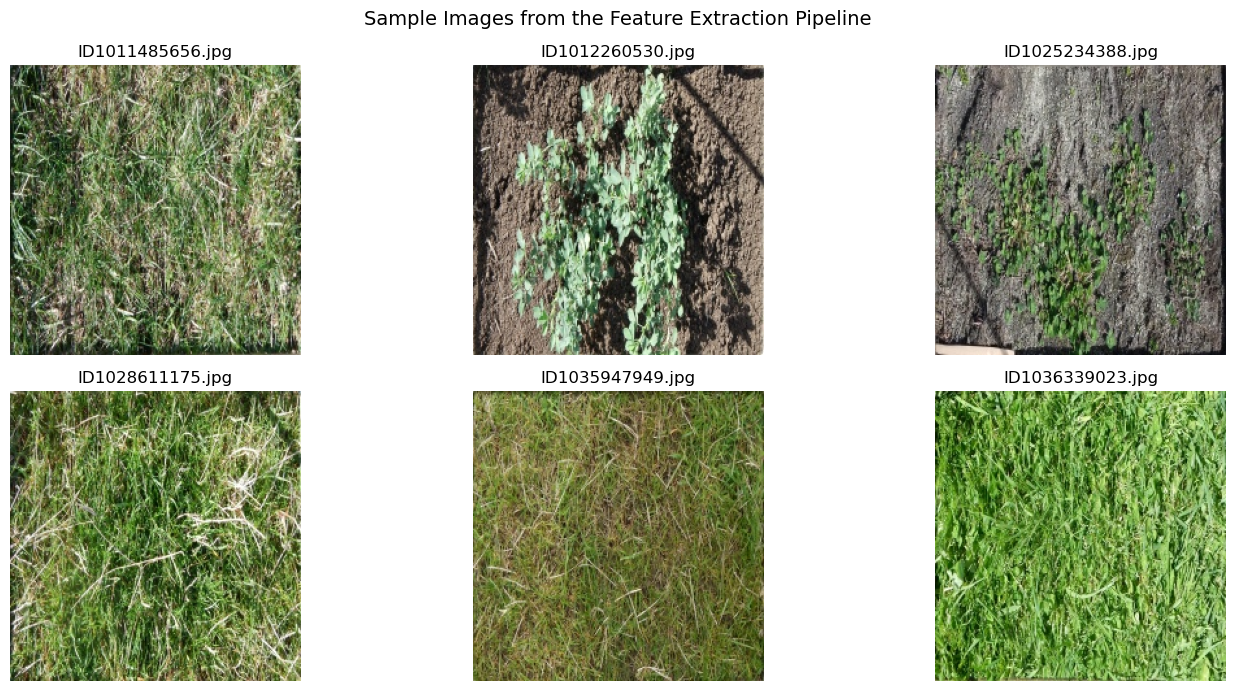

In [11]:
# Visualize a small sample from the validated image pipeline
n_display = 6

plt.figure(figsize=(15, 7))

for index in range(n_display):
    plt.subplot(2, 3, index + 1)

    image = sample_batch[index].numpy().astype(np.uint8)

    plt.imshow(image)
    plt.title(
        Path(ordered_image_paths[index]).name
    )
    plt.axis("off")

plt.suptitle(
    "Sample Images from the Feature Extraction Pipeline",
    fontsize=14,
)

plt.tight_layout()
plt.show()

## 3. Extract EfficientNetB0 CNN Embeddings

The validated image pipeline is now passed through the frozen EfficientNetB0 feature extractor.

Each of the 357 pasture images is converted into a 1280-dimensional numerical embedding representing high-level visual characteristics learned from ImageNet pretraining.

The extraction process:

- processes images in batches for computational efficiency;
- preserves the original metadata row order;
- does not update any EfficientNetB0 model parameters;
- does not use biomass targets during feature extraction;
- produces reusable embeddings that can be cached for downstream experiments.

The extraction time is measured to document the computational cost of generating the CNN feature representation.

In [12]:
# Measure CNN feature extraction time
extraction_start_time = time.perf_counter()

# Extract 1280-dimensional embeddings for all images
cnn_features = extract_cnn_features(
    model=feature_extractor,
    dataset=image_dataset,
    verbose=1,
)

extraction_end_time = time.perf_counter()
extraction_time = extraction_end_time - extraction_start_time

print("\nCNN feature extraction completed successfully.")

print(f"\nExtracted Feature Shape : {cnn_features.shape}")
print(f"Feature Dtype           : {cnn_features.dtype}")
print(f"Extraction Time         : {extraction_time:.2f} seconds")
print(f"Time per Image          : {extraction_time / len(feature_metadata):.4f} seconds")

12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 730ms/step

CNN feature extraction completed successfully.

Extracted Feature Shape : (357, 1280)
Feature Dtype           : float32
Extraction Time         : 12.14 seconds
Time per Image          : 0.0340 seconds


In [13]:
# Validate extracted EfficientNetB0 embeddings
cnn_validation_results = validate_cnn_features(
    features=cnn_features,
    expected_samples=len(feature_metadata),
    expected_dim=CNN_FEATURE_DIM,
)

print("=" * 60)
print("CNN FEATURE VALIDATION RESULTS")
print("=" * 60)

for metric, value in cnn_validation_results.items():
    print(f"{metric:<25}: {value}")

print("\nCNN feature validation passed successfully.")

CNN FEATURE VALIDATION RESULTS
n_samples                : 357
n_features               : 1280
dtype                    : float32
nan_count                : 0
inf_count                : 0
zero_variance_features   : 0
feature_min              : -0.27063310146331787
feature_max              : 4.566744804382324
feature_mean             : -0.022088544443249702
feature_std              : 0.3116857409477234

CNN feature validation passed successfully.


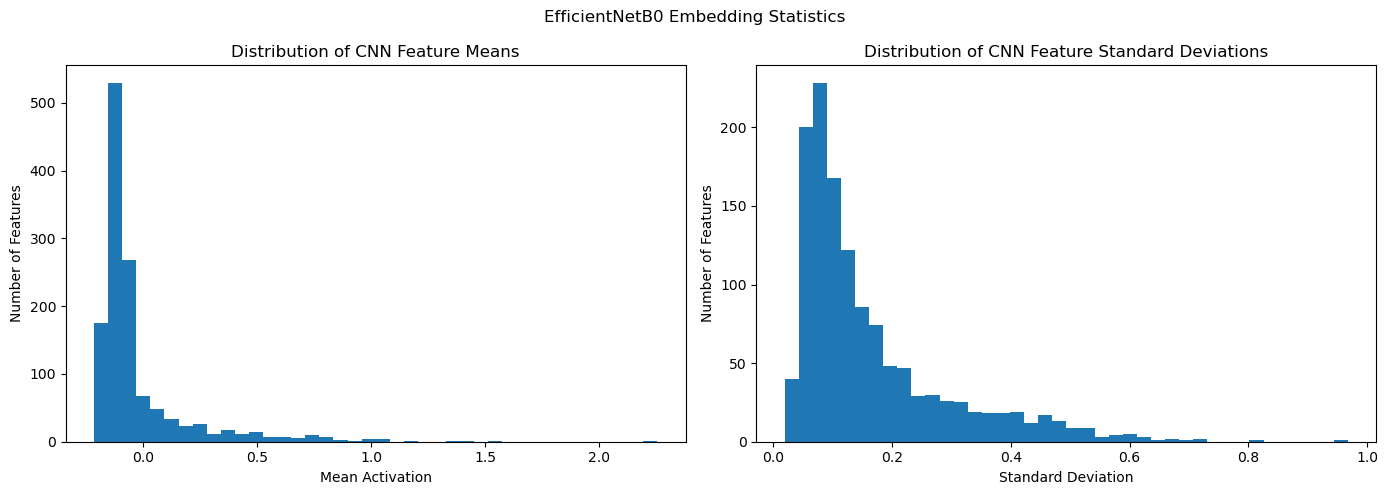

Minimum Feature Std : 0.019164
Maximum Feature Std : 0.967882
Mean Feature Std    : 0.163790


In [14]:
# Calculate per-feature statistics across all images
feature_means = np.mean(cnn_features, axis=0)
feature_stds = np.std(cnn_features, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(feature_means, bins=40)
axes[0].set_title("Distribution of CNN Feature Means")
axes[0].set_xlabel("Mean Activation")
axes[0].set_ylabel("Number of Features")

axes[1].hist(feature_stds, bins=40)
axes[1].set_title("Distribution of CNN Feature Standard Deviations")
axes[1].set_xlabel("Standard Deviation")
axes[1].set_ylabel("Number of Features")

plt.suptitle("EfficientNetB0 Embedding Statistics")
plt.tight_layout()
plt.show()

print(f"Minimum Feature Std : {feature_stds.min():.6f}")
print(f"Maximum Feature Std : {feature_stds.max():.6f}")
print(f"Mean Feature Std    : {feature_stds.mean():.6f}")

## 4. Cache EfficientNetB0 CNN Features

The validated EfficientNetB0 embeddings are cached to disk so that downstream notebooks can reuse them without repeating CNN inference.

Two complementary artifacts will be stored:

- a NumPy feature matrix containing the 1280-dimensional embeddings;
- an image mapping table preserving the exact relationship between feature row indices, original image paths, processed image paths, and cross-validation folds.

Separating the compact numerical feature matrix from its mapping metadata provides efficient storage while maintaining reproducible alignment with the original dataset.

In [15]:
# Define CNN cache artifact paths
cnn_features_path = (
    CACHED_FEATURES_DIR / "efficientnetb0_embeddings.npy"
)

cnn_mapping_path = (
    CACHED_FEATURES_DIR / "efficientnetb0_image_mapping.csv"
)

# Save CNN embedding matrix
np.save(
    cnn_features_path,
    cnn_features,
)

# Create row-aligned image mapping table
cnn_mapping = feature_metadata[
    [
        "image_path",
        "processed_image_path",
        "fold",
    ]
].copy()

cnn_mapping.insert(
    0,
    "feature_index",
    np.arange(len(cnn_mapping)),
)

# Save image mapping table
cnn_mapping.to_csv(
    cnn_mapping_path,
    index=False,
)

print("CNN feature artifacts saved successfully.")

print(f"\nCNN Features Path : {cnn_features_path}")
print(f"CNN Mapping Path  : {cnn_mapping_path}")

print(f"\nCNN Features Shape: {cnn_features.shape}")
print(f"CNN Mapping Shape : {cnn_mapping.shape}")

display(cnn_mapping.head())

CNN feature artifacts saved successfully.

CNN Features Path : E:\DATAVIDWAN\Image2Biomass\data\processed\cached_features\efficientnetb0_embeddings.npy
CNN Mapping Path  : E:\DATAVIDWAN\Image2Biomass\data\processed\cached_features\efficientnetb0_image_mapping.csv

CNN Features Shape: (357, 1280)
CNN Mapping Shape : (357, 4)


,feature_index,image_path,processed_image_path,fold
0,0,train/ID1011485656.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,3
1,1,train/ID1012260530.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,4
2,2,train/ID1025234388.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,1
3,3,train/ID1028611175.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,3
4,4,train/ID1035947949.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,0


In [16]:
# Reload cached CNN artifacts from disk
reloaded_cnn_features = np.load(cnn_features_path)
reloaded_cnn_mapping = pd.read_csv(cnn_mapping_path)

# Validate saved artifact shapes
assert reloaded_cnn_features.shape == cnn_features.shape, (
    "Reloaded CNN feature shape does not match the original."
)

assert reloaded_cnn_mapping.shape == cnn_mapping.shape, (
    "Reloaded CNN mapping shape does not match the original."
)

# Validate numerical equality
assert np.array_equal(
    reloaded_cnn_features,
    cnn_features,
), "Reloaded CNN features differ from the original features."

# Validate image ordering
assert reloaded_cnn_mapping["image_path"].tolist() == (
    feature_metadata["image_path"].tolist()
), "Image path ordering changed after saving."

# Validate fold alignment
assert reloaded_cnn_mapping["fold"].tolist() == (
    feature_metadata["fold"].tolist()
), "Fold alignment changed after saving."

# Validate feature indices
assert reloaded_cnn_mapping["feature_index"].tolist() == list(
    range(len(feature_metadata))
), "Feature index alignment is invalid."

print("=" * 60)
print("CACHED CNN ARTIFACT VALIDATION")
print("=" * 60)

print(f"\nReloaded Feature Shape : {reloaded_cnn_features.shape}")
print(f"Reloaded Mapping Shape : {reloaded_cnn_mapping.shape}")
print(f"Numerical Match        : True")
print(f"Image Order Preserved  : True")
print(f"Fold Alignment         : True")
print(f"Feature Index Alignment: True")

print("\nCached CNN artifacts validated successfully.")


CACHED CNN ARTIFACT VALIDATION

Reloaded Feature Shape : (357, 1280)
Reloaded Mapping Shape : (357, 4)
Numerical Match        : True
Image Order Preserved  : True
Fold Alignment         : True
Feature Index Alignment: True

Cached CNN artifacts validated successfully.


In [17]:
# Load raw training data to recover image-level metadata columns
from src.config import TRAIN_CSV

raw_train = pd.read_csv(TRAIN_CSV)

METADATA_COLUMNS = [
    "State",
    "Species",
    "Pre_GSHH_NDVI",
    "Height_Ave_cm",
]

# Validate required raw columns
required_raw_columns = ["image_path"] + METADATA_COLUMNS

missing_raw_columns = [
    column
    for column in required_raw_columns
    if column not in raw_train.columns
]

if missing_raw_columns:
    raise ValueError(
        f"Missing required raw metadata columns: {missing_raw_columns}"
    )

# Keep one metadata record per unique image
image_metadata = (
    raw_train[required_raw_columns]
    .drop_duplicates(subset="image_path")
    .reset_index(drop=True)
)

# Merge metadata with the validated fold assignment table
feature_metadata = feature_metadata.merge(
    image_metadata,
    on="image_path",
    how="left",
    validate="one_to_one",
)

print("=" * 60)
print("IMAGE-LEVEL METADATA ALIGNMENT")
print("=" * 60)

print(f"\nRaw Training Rows       : {len(raw_train)}")
print(f"Unique Metadata Images  : {len(image_metadata)}")
print(f"Aligned Feature Rows    : {len(feature_metadata)}")

print("\nMetadata Missing Values:")
print(feature_metadata[METADATA_COLUMNS].isna().sum())

print("\nMetadata Data Types:")
print(feature_metadata[METADATA_COLUMNS].dtypes)

display(
    feature_metadata[
        ["image_path", "fold"] + METADATA_COLUMNS
    ].head()
)

IMAGE-LEVEL METADATA ALIGNMENT

Raw Training Rows       : 1785
Unique Metadata Images  : 357
Aligned Feature Rows    : 357

Metadata Missing Values:
State            0
Species          0
Pre_GSHH_NDVI    0
Height_Ave_cm    0
dtype: int64

Metadata Data Types:
State             object
Species           object
Pre_GSHH_NDVI    float64
Height_Ave_cm    float64
dtype: object


,image_path,fold,State,Species,Pre_GSHH_NDVI,Height_Ave_cm
0,train/ID1011485656.jpg,3,Tas,Ryegrass_Clover,0.62,4.6667
1,train/ID1012260530.jpg,4,NSW,Lucerne,0.55,16.0000
2,train/ID1025234388.jpg,1,WA,SubcloverDalkeith,0.38,1.0000
3,train/ID1028611175.jpg,3,Tas,Ryegrass,0.66,5.0000
4,train/ID1035947949.jpg,0,Tas,Ryegrass,0.54,3.5000


In [18]:
# Import reusable metadata feature engineering utilities
from src.metadata_features import (
    CATEGORICAL_METADATA_COLUMNS,
    NUMERICAL_METADATA_COLUMNS,
    METADATA_COLUMNS,
    validate_metadata_columns,
    build_metadata_preprocessor,
    get_metadata_feature_names,
    generate_oof_metadata_features,
)

print("Metadata feature utilities imported successfully.")

print(f"\nCategorical Metadata Columns : {CATEGORICAL_METADATA_COLUMNS}")
print(f"Numerical Metadata Columns   : {NUMERICAL_METADATA_COLUMNS}")
print(f"All Metadata Columns         : {METADATA_COLUMNS}")

Metadata feature utilities imported successfully.

Categorical Metadata Columns : ['State', 'Species']
Numerical Metadata Columns   : ['Pre_GSHH_NDVI', 'Height_Ave_cm']
All Metadata Columns         : ['State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']


In [19]:
# Validate metadata before fold-safe feature generation
metadata_validation_results = validate_metadata_columns(
    feature_metadata
)

print("=" * 60)
print("METADATA INPUT VALIDATION")
print("=" * 60)

print(
    f"\nNumber of Samples         : "
    f"{metadata_validation_results['n_samples']}"
)

print(
    f"Number of Metadata Columns: "
    f"{metadata_validation_results['n_metadata_columns']}"
)

print("\nMissing Values by Column:")

for column, count in metadata_validation_results[
    "missing_value_counts"
].items():
    print(f"  {column:<20}: {count}")

print(
    f"\nTotal Missing Values      : "
    f"{metadata_validation_results['total_missing_values']}"
)

print("\nCategorical Cardinalities:")

for column in CATEGORICAL_METADATA_COLUMNS:
    print(
        f"  {column:<20}: "
        f"{feature_metadata[column].nunique()} unique values"
    )

print("\nNumerical Feature Statistics:")

display(
    feature_metadata[
        NUMERICAL_METADATA_COLUMNS
    ].describe().T
)

print("\nMetadata input validation passed successfully.")

METADATA INPUT VALIDATION

Number of Samples         : 357
Number of Metadata Columns: 4

Missing Values by Column:
  State               : 0
  Species             : 0
  Pre_GSHH_NDVI       : 0
  Height_Ave_cm       : 0

Total Missing Values      : 0

Categorical Cardinalities:
  State               : 4 unique values
  Species             : 15 unique values

Numerical Feature Statistics:


,count,mean,std,min,25%,50%,75%,max
Pre_GSHH_NDVI,357.0,0.657423,0.152142,0.16,0.56,0.69,0.77,0.91
Height_Ave_cm,357.0,7.595985,10.285262,1.00,3.00,4.00,7.00,70.00



Metadata input validation passed successfully.


## 5. Generate Fold-Safe Metadata Features

The image-level metadata variables are transformed into numerical features for downstream regression models.

The preprocessing pipeline applies:

- median imputation and standardization to `Pre_GSHH_NDVI` and `Height_Ave_cm`;
- most-frequent imputation and one-hot encoding to `State` and `Species`;
- independent fitting of the preprocessing pipeline within each cross-validation training fold.

For every fold, the metadata preprocessor is fitted only on samples belonging to the other four folds. The held-out validation fold is then transformed using that fitted preprocessor.

This out-of-fold procedure prevents validation information from influencing fitted scaling or categorical preprocessing parameters and preserves the original row ordering of the 357 image-level samples.

In [20]:
# Generate fold-safe out-of-fold metadata features
metadata_oof_features, metadata_feature_names, fitted_preprocessors = (
    generate_oof_metadata_features(
        metadata=feature_metadata,
        fold_column="fold",
    )
)

print("=" * 60)
print("OOF METADATA FEATURE GENERATION")
print("=" * 60)

print(f"\nOOF Feature Shape       : {metadata_oof_features.shape}")
print(f"Feature Dtype           : {metadata_oof_features.dtype}")
print(f"Number of Feature Names : {len(metadata_feature_names)}")
print(f"Fitted Preprocessors    : {sorted(fitted_preprocessors.keys())}")

print("\nGenerated Metadata Features:")

for index, feature_name in enumerate(metadata_feature_names):
    print(f"  {index:>2} : {feature_name}")

print("\nFold-safe OOF metadata features generated successfully.")

OOF METADATA FEATURE GENERATION

OOF Feature Shape       : (357, 21)
Feature Dtype           : float32
Number of Feature Names : 21
Fitted Preprocessors    : [0, 1, 2, 3, 4]

Generated Metadata Features:
   0 : Pre_GSHH_NDVI
   1 : Height_Ave_cm
   2 : State_NSW
   3 : State_Tas
   4 : State_Vic
   5 : State_WA
   6 : Species_Clover
   7 : Species_Fescue
   8 : Species_Fescue_CrumbWeed
   9 : Species_Lucerne
  10 : Species_Mixed
  11 : Species_Phalaris
  12 : Species_Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed
  13 : Species_Phalaris_Clover
  14 : Species_Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass
  15 : Species_Phalaris_Ryegrass_Clover
  16 : Species_Ryegrass
  17 : Species_Ryegrass_Clover
  18 : Species_SubcloverDalkeith
  19 : Species_SubcloverLosa
  20 : Species_WhiteClover

Fold-safe OOF metadata features generated successfully.


In [21]:
# Validate generated OOF metadata features
metadata_nan_count = int(
    np.isnan(metadata_oof_features).sum()
)

metadata_inf_count = int(
    np.isinf(metadata_oof_features).sum()
)

metadata_feature_variances = np.var(
    metadata_oof_features,
    axis=0,
)

metadata_zero_variance_count = int(
    np.sum(metadata_feature_variances == 0)
)

print("=" * 60)
print("OOF METADATA FEATURE VALIDATION")
print("=" * 60)

print(f"\nNumber of Samples       : {metadata_oof_features.shape[0]}")
print(f"Number of Features      : {metadata_oof_features.shape[1]}")
print(f"Feature Dtype           : {metadata_oof_features.dtype}")

print(f"\nNaN Count               : {metadata_nan_count}")
print(f"Infinite Count          : {metadata_inf_count}")
print(f"Zero-Variance Features  : {metadata_zero_variance_count}")

print(f"\nFeature Minimum         : {metadata_oof_features.min():.6f}")
print(f"Feature Maximum         : {metadata_oof_features.max():.6f}")
print(f"Feature Mean            : {metadata_oof_features.mean():.6f}")
print(f"Feature Standard Dev.   : {metadata_oof_features.std():.6f}")

# Structural and numerical assertions
assert metadata_oof_features.shape[0] == len(feature_metadata), (
    "Metadata feature row count does not match the source metadata."
)

assert metadata_oof_features.shape[1] == len(metadata_feature_names), (
    "Metadata feature count does not match feature names."
)

assert metadata_nan_count == 0, (
    "OOF metadata features contain NaN values."
)

assert metadata_inf_count == 0, (
    "OOF metadata features contain infinite values."
)

print("\nOOF metadata feature validation passed successfully.")

OOF METADATA FEATURE VALIDATION

Number of Samples       : 357
Number of Features      : 21
Feature Dtype           : float32

NaN Count               : 0
Infinite Count          : 0
Zero-Variance Features  : 0

Feature Minimum         : -3.345584
Feature Maximum         : 6.561700
Feature Mean            : 0.095358
Feature Standard Dev.   : 0.429476

OOF metadata feature validation passed successfully.


In [22]:
import joblib

# Define metadata artifact paths
metadata_features_path = (
    FEATURE_TABLE_DIR / "metadata_oof_features.csv"
)

metadata_preprocessor_dir = (
    CACHED_FEATURES_DIR / "metadata_preprocessors"
)

metadata_preprocessor_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# Create metadata feature table
metadata_feature_table = pd.DataFrame(
    metadata_oof_features,
    columns=metadata_feature_names,
)

# Preserve identifiers and fold assignments
metadata_feature_table.insert(
    0,
    "fold",
    feature_metadata["fold"].to_numpy(),
)

metadata_feature_table.insert(
    0,
    "image_path",
    feature_metadata["image_path"].to_numpy(),
)

# Save OOF metadata feature table
metadata_feature_table.to_csv(
    metadata_features_path,
    index=False,
)

# Save each fitted fold preprocessor
for fold, preprocessor in fitted_preprocessors.items():

    preprocessor_path = (
        metadata_preprocessor_dir
        / f"metadata_preprocessor_fold_{fold}.joblib"
    )

    joblib.dump(
        preprocessor,
        preprocessor_path,
    )

print("Metadata artifacts saved successfully.")

print(f"\nMetadata Feature Path : {metadata_features_path}")
print(f"Preprocessor Directory: {metadata_preprocessor_dir}")

print(f"\nMetadata Table Shape  : {metadata_feature_table.shape}")
print(f"Saved Preprocessors   : {len(fitted_preprocessors)}")

display(metadata_feature_table.head())

Metadata artifacts saved successfully.

Metadata Feature Path : E:\DATAVIDWAN\Image2Biomass\data\processed\feature_tables\metadata_oof_features.csv
Preprocessor Directory: E:\DATAVIDWAN\Image2Biomass\data\processed\cached_features\metadata_preprocessors

Metadata Table Shape  : (357, 23)
Saved Preprocessors   : 5


,image_path,fold,Pre_GSHH_NDVI,Height_Ave_cm,State_NSW,State_Tas,State_Vic,State_WA,Species_Clover,Species_Fescue,...,Species_Phalaris,Species_Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed,Species_Phalaris_Clover,Species_Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass,Species_Phalaris_Ryegrass_Clover,Species_Ryegrass,Species_Ryegrass_Clover,Species_SubcloverDalkeith,Species_SubcloverLosa,Species_WhiteClover
0,train/ID1011485656.jpg,3,-0.244040,-0.283154,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,train/ID1012260530.jpg,4,-0.634502,0.821992,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,train/ID1025234388.jpg,1,-1.851811,-0.631375,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,train/ID1028611175.jpg,3,0.017122,-0.249376,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,train/ID1035947949.jpg,0,-0.805080,-0.396204,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 6. Create Combined Feature Table

The cached EfficientNetB0 embeddings and fold-safe metadata features are now combined into a single modeling table.

The combined representation contains:

- 1280 pretrained CNN embedding features;
- 21 fold-safe metadata features;
- original image identifiers;
- processed image paths;
- cross-validation fold assignments;
- all five biomass regression targets.

The resulting table provides a row-aligned and reusable input artifact for `04_baseline_models.ipynb`.

CNN and metadata features remain distinguishable through explicit feature name prefixes, allowing downstream experiments to compare image-only, metadata-only, and combined feature representations.

In [23]:
# Create descriptive CNN feature names
cnn_feature_names = [
    f"cnn_{index:04d}"
    for index in range(CNN_FEATURE_DIM)
]

# Create CNN feature DataFrame
cnn_feature_table = pd.DataFrame(
    cnn_features,
    columns=cnn_feature_names,
)

# Create combined feature table
combined_feature_table = pd.concat(
    [
        feature_metadata[
            [
                "image_path",
                "processed_image_path",
                "fold",
            ]
            + TARGET_COLUMNS
        ].reset_index(drop=True),

        cnn_feature_table.reset_index(drop=True),

        metadata_feature_table[
            metadata_feature_names
        ].reset_index(drop=True),
    ],
    axis=1,
)

# Define output path
combined_features_path = (
    FEATURE_TABLE_DIR / "combined_features.csv"
)

# Save combined feature table
combined_feature_table.to_csv(
    combined_features_path,
    index=False,
)

print("=" * 60)
print("COMBINED FEATURE TABLE")
print("=" * 60)

print(f"\nNumber of Samples        : {len(combined_feature_table)}")
print(f"CNN Features             : {len(cnn_feature_names)}")
print(f"Metadata Features        : {len(metadata_feature_names)}")
print(
    f"Total Predictive Features: "
    f"{len(cnn_feature_names) + len(metadata_feature_names)}"
)
print(f"Total Table Columns      : {combined_feature_table.shape[1]}")

print(f"\nSaved Path:")
print(combined_features_path)

display(
    combined_feature_table[
        [
            "image_path",
            "fold",
            *TARGET_COLUMNS,
            "cnn_0000",
            "cnn_0001",
            *metadata_feature_names[:4],
        ]
    ].head()
)

COMBINED FEATURE TABLE

Number of Samples        : 357
CNN Features             : 1280
Metadata Features        : 21
Total Predictive Features: 1301
Total Table Columns      : 1309

Saved Path:
E:\DATAVIDWAN\Image2Biomass\data\processed\feature_tables\combined_features.csv


,image_path,fold,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,cnn_0000,cnn_0001,Pre_GSHH_NDVI,Height_Ave_cm,State_NSW,State_Tas
0,train/ID1011485656.jpg,3,0.0000,31.9984,16.2751,48.2735,16.2750,-0.129528,-0.114636,-0.244040,-0.283154,0.0,1.0
1,train/ID1012260530.jpg,4,0.0000,0.0000,7.6000,7.6000,7.6000,0.230389,-0.185907,-0.634502,0.821992,1.0,0.0
2,train/ID1025234388.jpg,1,6.0500,0.0000,0.0000,6.0500,6.0500,0.078159,-0.212043,-1.851811,-0.631375,0.0,0.0
3,train/ID1028611175.jpg,3,0.0000,30.9703,24.2376,55.2079,24.2376,-0.132350,-0.141714,0.017122,-0.249376,0.0,1.0
4,train/ID1035947949.jpg,0,0.4343,23.2239,10.5261,34.1844,10.9605,-0.170238,-0.080727,-0.805080,-0.396204,0.0,1.0


In [24]:
# Reload all primary artifacts from disk
final_cnn_features = np.load(cnn_features_path)
final_cnn_mapping = pd.read_csv(cnn_mapping_path)
final_metadata_features = pd.read_csv(metadata_features_path)
final_combined_features = pd.read_csv(combined_features_path)

# Identify predictive feature columns
final_cnn_columns = [
    column
    for column in final_combined_features.columns
    if column.startswith("cnn_")
]

final_metadata_columns = [
    column
    for column in metadata_feature_names
    if column in final_combined_features.columns
]

# Validate artifact dimensions
assert final_cnn_features.shape == (357, CNN_FEATURE_DIM)
assert final_cnn_mapping.shape[0] == 357
assert final_metadata_features.shape == (357, 23)
assert final_combined_features.shape == (357, 1309)

# Validate predictive feature counts
assert len(final_cnn_columns) == 1280
assert len(final_metadata_columns) == 21

# Validate row alignment across artifacts
assert final_cnn_mapping["image_path"].tolist() == (
    final_combined_features["image_path"].tolist()
)

assert final_metadata_features["image_path"].tolist() == (
    final_combined_features["image_path"].tolist()
)

assert final_cnn_mapping["fold"].tolist() == (
    final_combined_features["fold"].tolist()
)

assert final_metadata_features["fold"].tolist() == (
    final_combined_features["fold"].tolist()
)

# Validate targets
assert final_combined_features[TARGET_COLUMNS].isna().sum().sum() == 0

assert np.isfinite(
    final_combined_features[TARGET_COLUMNS].to_numpy()
).all()

# Validate predictive features
all_predictive_columns = (
    final_cnn_columns
    + final_metadata_columns
)

predictive_values = final_combined_features[
    all_predictive_columns
].to_numpy()

assert np.isfinite(predictive_values).all()

# Validate saved preprocessors
saved_preprocessor_files = sorted(
    metadata_preprocessor_dir.glob(
        "metadata_preprocessor_fold_*.joblib"
    )
)

assert len(saved_preprocessor_files) == N_FOLDS

print("=" * 60)
print("FINAL FEATURE ARTIFACT INTEGRITY VALIDATION")
print("=" * 60)

print(f"\nSamples                  : {len(final_combined_features)}")
print(f"CNN Features             : {len(final_cnn_columns)}")
print(f"Metadata Features        : {len(final_metadata_columns)}")
print(f"Total Predictive Features: {len(all_predictive_columns)}")
print(f"Target Columns           : {len(TARGET_COLUMNS)}")
print(f"Cross-Validation Folds   : {final_combined_features['fold'].nunique()}")
print(f"Saved Preprocessors      : {len(saved_preprocessor_files)}")

print("\nNaN Predictive Values    :", np.isnan(predictive_values).sum())
print("Infinite Predictive Values:", np.isinf(predictive_values).sum())

print("\nRow Alignment            : PASSED")
print("Target Validation        : PASSED")
print("Feature Validation       : PASSED")
print("Artifact Reload          : PASSED")

print("\nAll feature artifacts validated successfully.")

FINAL FEATURE ARTIFACT INTEGRITY VALIDATION

Samples                  : 357
CNN Features             : 1280
Metadata Features        : 21
Total Predictive Features: 1301
Target Columns           : 5
Cross-Validation Folds   : 5
Saved Preprocessors      : 5

NaN Predictive Values    : 0
Infinite Predictive Values: 0

Row Alignment            : PASSED
Target Validation        : PASSED
Feature Validation       : PASSED
Artifact Reload          : PASSED

All feature artifacts validated successfully.


## 7. Notebook Summary and Next Steps

### Feature Extraction Summary

This notebook successfully generated and validated reusable image and metadata features for the CSIRO Image2Biomass prediction pipeline.

#### CNN Feature Extraction

- Loaded all 357 processed pasture images.
- Initialized EfficientNetB0 with pretrained ImageNet weights.
- Configured the CNN backbone as a fully frozen feature extractor.
- Built an efficient batched TensorFlow input pipeline.
- Extracted 1280-dimensional embeddings from every image.
- Validated embedding dimensions, numerical integrity, and feature variation.
- Cached the embeddings and their row-aligned image mapping for reuse.

#### Metadata Feature Engineering

The following image-level metadata variables were processed:

- `State`
- `Species`
- `Pre_GSHH_NDVI`
- `Height_Ave_cm`

A fold-safe preprocessing strategy was used to prevent cross-validation leakage.

For every validation fold:

- preprocessing transformations were fitted using only the corresponding training folds;
- numerical variables were imputed and standardized;
- categorical variables were imputed and one-hot encoded;
- the validation fold was transformed using the fitted training-fold preprocessor.

The resulting metadata representation contains 21 features, and all five fitted fold preprocessors were saved for reproducible downstream use.

#### Final Feature Representation

The combined modeling dataset contains:

| Component | Count |
|---|---:|
| Image-level samples | 357 |
| EfficientNetB0 CNN features | 1280 |
| Metadata features | 21 |
| Total predictive features | 1301 |
| Biomass regression targets | 5 |
| Cross-validation folds | 5 |

#### Generated Artifacts

CNN feature cache:

- `data/processed/cached_features/efficientnetb0_embeddings.npy`
- `data/processed/cached_features/efficientnetb0_image_mapping.csv`

Fold-specific metadata preprocessors:

- `data/processed/cached_features/metadata_preprocessors/metadata_preprocessor_fold_0.joblib`
- `data/processed/cached_features/metadata_preprocessors/metadata_preprocessor_fold_1.joblib`
- `data/processed/cached_features/metadata_preprocessors/metadata_preprocessor_fold_2.joblib`
- `data/processed/cached_features/metadata_preprocessors/metadata_preprocessor_fold_3.joblib`
- `data/processed/cached_features/metadata_preprocessors/metadata_preprocessor_fold_4.joblib`

Feature tables:

- `data/processed/feature_tables/metadata_oof_features.csv`
- `data/processed/feature_tables/combined_features.csv`

### Final Validation Status

- CNN feature dimensions validated.
- Metadata feature dimensions validated.
- No missing predictive values detected.
- No infinite predictive values detected.
- Image ordering preserved across all artifacts.
- Cross-validation fold assignments preserved.
- Biomass targets preserved.
- Saved artifacts successfully reloaded and validated.

### Next Step

The generated feature artifacts are ready for `04_baseline_models.ipynb`.

The next notebook will establish cross-validated regression baselines and compare image-only, metadata-only, and combined feature representations for predicting the five biomass targets.